# 07c — Entrenamiento split por bloques + normalización propia (v2_tuned)

Segunda corrida sobre el **mismo split** de `06_split_bloques.ipynb` (`v2_bloques`), cambiando
únicamente la normalización de entrada: en lugar de las constantes ImageNet se usan las medidas
sobre train en `03b_normalizacion_chips.ipynb` (`data/08_reporting/normalization_constants.json`).

`ColorJitter` se mantiene (03b no encontró degradación medible de la señal fotométrica).
No se modifica `src/data/dataset.py` ni los notebooks `07`/`08` originales.

Salidas bajo `v2_bloques_tuned/`:

```text
data/06_models/v2_bloques_tuned/{arquitectura}_best.pt
data/08_reporting/v2_bloques_tuned/...
reports/figures/{arquitectura}_v2_bloques_tuned_training_curves.png
```

Manifiestos reutilizados de `data/05_model_input/v2_bloques/` (no reejecutar el 06).


## 1. Configuración

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import GarimpoDataset, load_manifest
from src.models.train import train_model
from src.utils.helpers import get_device, set_seed

RUN_NAME = "v2_bloques_tuned"
SPLIT_NAME = "v2_bloques"  # manifiestos del 06; no reentrenar split

DATA_DIR = ROOT / "data"
MANIFEST_DIR = DATA_DIR / "05_model_input" / SPLIT_NAME
MODELS_DIR = DATA_DIR / "06_models" / RUN_NAME
REPORT_DIR = DATA_DIR / "08_reporting" / RUN_NAME
FIGURES_DIR = ROOT / "reports" / "figures"
MODELS_DIR = DATA_DIR / "06_models" / RUN_NAME
REPORT_DIR = DATA_DIR / "08_reporting" / RUN_NAME
FIGURES_DIR = ROOT / "reports" / "figures"

# La carpeta de chips no está en el mismo sitio en todas las máquinas del proyecto
CHIPS_DIR_CANDIDATOS = [
    DATA_DIR / "01_raw" / "dataset_amazonia_garimpo_binario",
    DATA_DIR / "Dataset" / "datasets" / "amazonia_garimpo" / "dataset_amazonia_garimpo_binario",
]
CHIPS_DIR = next((p for p in CHIPS_DIR_CANDIDATOS if p.exists()), None)
if CHIPS_DIR is None:
    rutas = "\n  ".join(str(p) for p in CHIPS_DIR_CANDIDATOS)
    raise FileNotFoundError(f"No se encontró la carpeta de chips. Probadas:\n  {rutas}")

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_EPOCHS = 30
PATIENCE = 7
LR_CNN = 1e-4
LR_TRANSFORMER = 3e-5
SEED = 42

MODELS = [
    {"name": "efficientnet_b0",              "label": "EfficientNet-B0 (v2 bloques tuned)",  "lr": LR_CNN},
    {"name": "resnet50",                     "label": "ResNet-50 (v2 bloques tuned)",        "lr": LR_CNN},
    {"name": "swin_tiny_patch4_window7_224", "label": "Swin Transformer (v2 bloques tuned)", "lr": LR_TRANSFORMER},
    {"name": "vit_tiny_patch16_224",         "label": "ViT tiny (v2 bloques tuned)",         "lr": LR_TRANSFORMER},
]

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
device = get_device()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else str(device)

print(f"Corrida: {RUN_NAME}")
print(f"Device: {device}")
print(f"GPU: {gpu_name}")
print(f"PyTorch: {torch.__version__}")
print(f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE}")
print(f"LR CNN={LR_CNN} | LR Transformer={LR_TRANSFORMER}")
print(f"Chips       : {CHIPS_DIR}")
print(f"Manifiestos : {MANIFEST_DIR}")
print(f"Checkpoints : {MODELS_DIR}")


c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corrida: v2_bloques_tuned
Device: cuda
GPU: NVIDIA GeForce RTX 5060
PyTorch: 2.12.0.dev20260408+cu128
Batch=32 | Max epochs=30 | Patience=7
LR CNN=0.0001 | LR Transformer=3e-05
Chips       : C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\01_raw\dataset_amazonia_garimpo_binario
Manifiestos : C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\05_model_input\v2_bloques
Checkpoints : C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\v2_bloques_tuned


## 2. Transforms y DataLoaders

Los manifiestos son los de `v2_bloques` (split ya validado). Los transforms viven **en este
notebook** con `DATASET_MEAN` / `DATASET_STD` medidos sobre train. `ColorJitter` se conserva
igual que en la corrida v2.


In [2]:
import json
from torchvision import transforms

NORM_JSON = DATA_DIR / "08_reporting" / "normalization_constants.json"
if not NORM_JSON.exists():
    raise FileNotFoundError(
        f"No se encontró {NORM_JSON}. Ejecuta antes 03b_normalizacion_chips.ipynb."
    )
_norm = json.loads(NORM_JSON.read_text(encoding="utf-8"))
DATASET_MEAN = tuple(_norm["DATASET_MEAN"])
DATASET_STD = tuple(_norm["DATASET_STD"])
print(f"Normalización propia (desde {NORM_JSON.name}):")
print(f"  DATASET_MEAN = {DATASET_MEAN}")
print(f"  DATASET_STD  = {DATASET_STD}")


def get_transforms_tuned(split: str) -> transforms.Compose:
    """Mismos augments que get_transforms(), con normalización medida sobre train."""
    normalize = transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
    if split == "train":
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.1,
                hue=0.05,
            ),
            transforms.ToTensor(),
            normalize,
        ])
    return transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])


Normalización propia (desde normalization_constants.json):
  DATASET_MEAN = (0.0303, 0.0813, 0.0202)
  DATASET_STD  = (0.0831, 0.0541, 0.0382)


In [3]:
def crear_dataloaders(
    manifest_dir: Path,
    chips_dir: Path,
    batch_size: int,
    num_workers: int,
) -> dict[str, DataLoader]:
    """DataLoaders a partir de los manifiestos de una corrida concreta."""
    loaders: dict[str, DataLoader] = {}
    for split in ("train", "val", "test"):
        manifest = load_manifest(manifest_dir / f"manifest_{split}.csv")
        dataset = GarimpoDataset(
            manifest=manifest,
            chips_dir=chips_dir,
            transform=get_transforms_tuned(split),
        )
        loaders[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=num_workers,
            pin_memory=True,
            persistent_workers=(num_workers > 0),
        )
    return loaders


loaders = crear_dataloaders(MANIFEST_DIR, CHIPS_DIR, BATCH_SIZE, NUM_WORKERS)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

for split, loader in loaders.items():
    manifest = loader.dataset.manifest
    print(
        f"{split:<5} {len(manifest):>7,} chips | "
        f"{len(loader):>5,} batches | "
        f"com_garimpo {manifest['label_int'].mean() * 100:5.1f} %"
    )


train  71,592 chips | 2,238 batches | com_garimpo  49.5 %
val    16,518 chips |   517 batches | com_garimpo  51.1 %
test   17,312 chips |   541 batches | com_garimpo  50.2 %


## 3. Helpers — gráficos y exportación

In [4]:
def history_to_dataframe(summary: dict) -> pd.DataFrame:
    """Combina métricas train/val por epoch en un DataFrame."""
    train_df = pd.DataFrame(summary["history"]["train"]).add_prefix("train_")
    val_df = pd.DataFrame(summary["history"]["val"]).add_prefix("val_")
    if "train_epoch" in train_df.columns:
        train_df = train_df.rename(columns={"train_epoch": "epoch"})
    if "val_epoch" in val_df.columns:
        val_df = val_df.drop(columns=["val_epoch"])
    df = pd.concat([train_df, val_df], axis=1)
    df.insert(0, "model", summary.get("model_label", summary["model_name"]))
    df.insert(1, "timm_name", summary["model_name"])
    return df


def plot_training_curves(summary: dict, save_path: Path) -> None:
    history = summary["history"]
    label = summary.get("model_label", summary["model_name"])
    epochs = [r["epoch"] for r in history["train"]]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(epochs, [r["loss"] for r in history["train"]], label="train")
    axes[0].plot(epochs, [r["loss"] for r in history["val"]], label="val")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("epoch")

    axes[1].plot(epochs, [r["accuracy"] for r in history["train"]], label="train")
    axes[1].plot(epochs, [r["accuracy"] for r in history["val"]], label="val")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("epoch")

    axes[2].plot(epochs, [r["macro_f1"] for r in history["val"]], label="val macro F1", color="tomato")
    axes[2].plot(epochs, [r["recall_com_garimpo"] for r in history["val"]], label="val recall com_garimpo")
    axes[2].set_title("Val F1 / Recall com_garimpo"); axes[2].legend(); axes[2].set_xlabel("epoch")

    plt.suptitle(f"{label} — curvas de entrenamiento", y=1.02)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def format_epoch_line(epoch: int, max_ep: int, train_r: dict, val_r: dict, elapsed: float) -> str:
    return (
        f"Epoch {epoch:02d}/{max_ep} | "
        f"train loss {train_r['loss']:.4f} acc {train_r['accuracy']:.3f} | "
        f"val loss {val_r['loss']:.4f} acc {val_r['accuracy']:.3f} "
        f"F1 {val_r['macro_f1']:.3f} "
        f"(com recall {val_r['recall_com_garimpo']:.3f}) | "
        f"{elapsed:.0f}s"
    )

## 4. Entrenar los 4 modelos sobre el split por bloques


[1/4] Entrenando: EfficientNet-B0 (v2 bloques tuned) (efficientnet_b0) | LR=0.0001


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando efficientnet_b0 en cuda (AMP activado)
Train: 71,592 | Val: 16,518


Epoch 01/30 | train loss 1.0299 acc 0.663 | val loss 0.6811 acc 0.767 F1 0.765 (com recall 0.671) | 201s
  → Mejor modelo guardado (macro F1 = 0.7650)


Epoch 02/30 | train loss 0.5393 acc 0.725 | val loss 0.4266 acc 0.800 F1 0.799 (com recall 0.716) | 141s
  → Mejor modelo guardado (macro F1 = 0.7987)


...

Epoch 08/30 | train loss 0.4410 acc 0.783 | val loss 0.4294 acc 0.779 F1 0.778 (com recall 0.844) | 142s


Epoch 09/30 | train loss 0.4363 acc 0.785 | val loss 0.4652 acc 0.779 F1 0.778 (com recall 0.825) | 143s


Epoch 10/30 | train loss 0.4268 acc 0.791 | val loss 0.4080 acc 0.799 F1 0.799 (com recall 0.747) | 143s


Epoch 11/30 | train loss 0.4222 acc 0.794 | val loss 0.4279 acc 0.794 F1 0.794 (com recall 0.738) | 143s


Epoch 12/30 | train loss 0.4168 acc 0.798 | val loss 0.4081 acc 0.799 F1 0.799 (com recall 0.778) | 142s
Early stopping en epoch 12 (sin mejora en 7 epochs)

Listo. Mejor epoch: 5 | val macro F1: 0.8141
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\v2_bloques_tuned\efficientnet_b0_best.pt


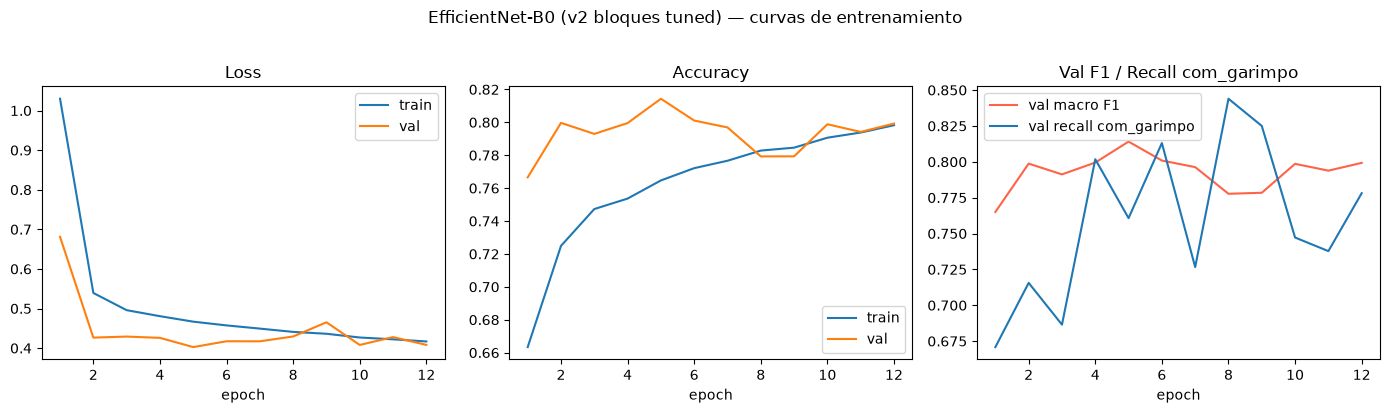


[2/4] Entrenando: ResNet-50 (v2 bloques tuned) (resnet50) | LR=0.0001


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando resnet50 en cuda (AMP activado)
Train: 71,592 | Val: 16,518


Epoch 01/30 | train loss 0.5555 acc 0.705 | val loss nan acc 0.805 F1 0.804 (com recall 0.750) | 138s
  → Mejor modelo guardado (macro F1 = 0.8044)


Epoch 02/30 | train loss 0.5068 acc 0.738 | val loss nan acc 0.800 F1 0.799 (com recall 0.719) | 112s


...

Epoch 12/30 | train loss 0.4358 acc 0.785 | val loss 0.3891 acc 0.812 F1 0.812 (com recall 0.774) | 89s


Epoch 13/30 | train loss 0.4337 acc 0.785 | val loss 0.3841 acc 0.811 F1 0.811 (com recall 0.793) | 89s


Epoch 14/30 | train loss 0.4290 acc 0.789 | val loss 0.3949 acc 0.802 F1 0.801 (com recall 0.836) | 91s


Epoch 15/30 | train loss 0.4224 acc 0.794 | val loss 0.3985 acc 0.805 F1 0.805 (com recall 0.784) | 91s


Epoch 16/30 | train loss 0.4213 acc 0.793 | val loss 0.4013 acc 0.800 F1 0.800 (com recall 0.836) | 89s
Early stopping en epoch 16 (sin mejora en 7 epochs)

Listo. Mejor epoch: 9 | val macro F1: 0.8181
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\v2_bloques_tuned\resnet50_best.pt


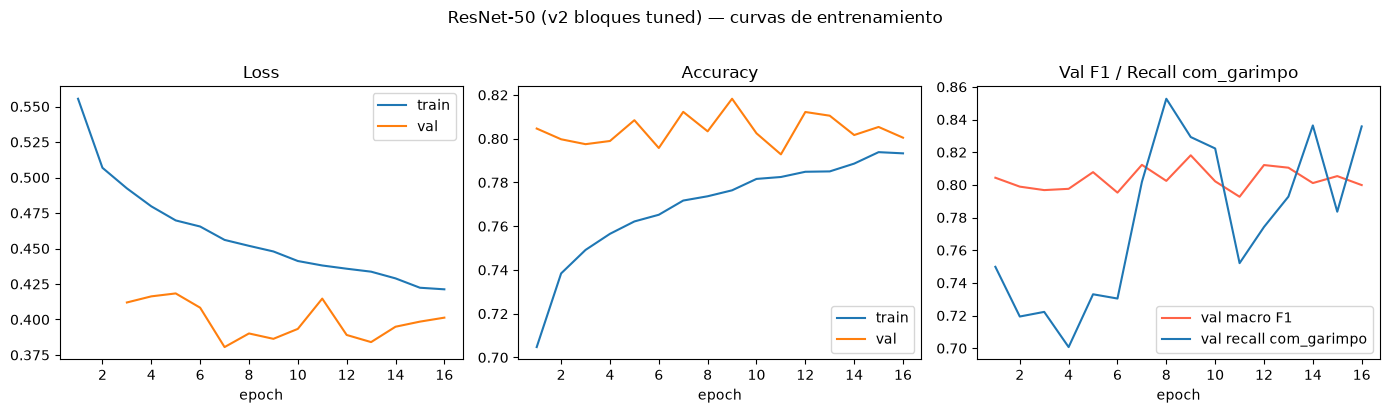


[3/4] Entrenando: Swin Transformer (v2 bloques tuned) (swin_tiny_patch4_window7_224) | LR=3e-05


c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)
c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an 

Entrenando swin_tiny_patch4_window7_224 en cuda (AMP activado)
Train: 71,592 | Val: 16,518


Epoch 01/30 | train loss 0.5037 acc 0.738 | val loss 0.4034 acc 0.812 F1 0.811 (com recall 0.881) | 138s
  → Mejor modelo guardado (macro F1 = 0.8106)


Epoch 02/30 | train loss 0.4679 acc 0.762 | val loss 0.3811 acc 0.820 F1 0.818 (com recall 0.888) | 138s
  → Mejor modelo guardado (macro F1 = 0.8185)


...

Epoch 05/30 | train loss 0.4312 acc 0.785 | val loss 0.4006 acc 0.792 F1 0.790 (com recall 0.884) | 137s


Epoch 06/30 | train loss 0.4231 acc 0.792 | val loss 0.3820 acc 0.807 F1 0.807 (com recall 0.839) | 137s


Epoch 07/30 | train loss 0.4152 acc 0.796 | val loss 0.3789 acc 0.815 F1 0.814 (com recall 0.872) | 137s


Epoch 08/30 | train loss 0.4084 acc 0.800 | val loss 0.3966 acc 0.796 F1 0.793 (com recall 0.898) | 138s


Epoch 09/30 | train loss 0.4013 acc 0.803 | val loss 0.3974 acc 0.806 F1 0.806 (com recall 0.801) | 137s
Early stopping en epoch 9 (sin mejora en 7 epochs)

Listo. Mejor epoch: 2 | val macro F1: 0.8185
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\v2_bloques_tuned\swin_tiny_patch4_window7_224_best.pt


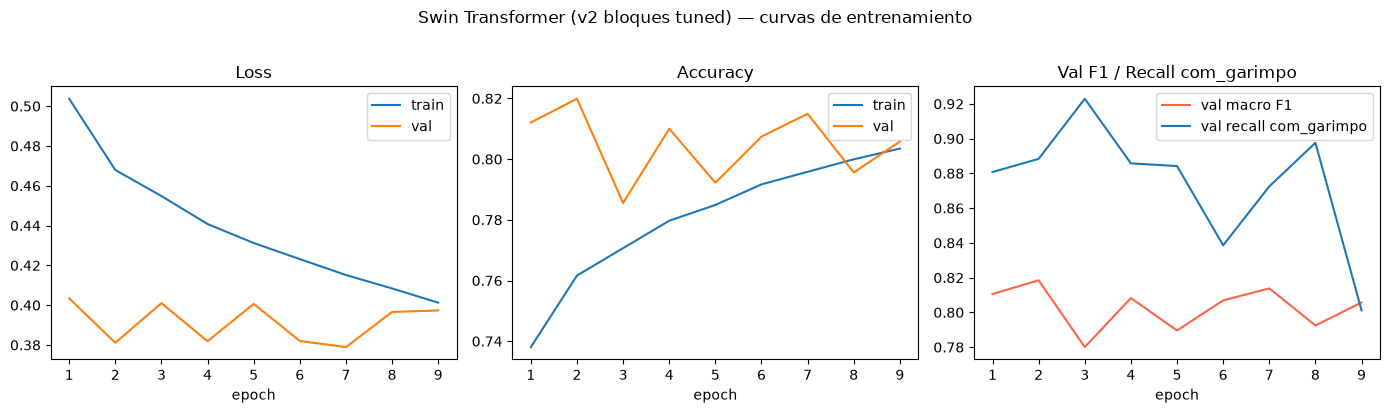


[4/4] Entrenando: ViT tiny (v2 bloques tuned) (vit_tiny_patch16_224) | LR=3e-05


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando vit_tiny_patch16_224 en cuda (AMP activado)
Train: 71,592 | Val: 16,518


Epoch 01/30 | train loss 0.5210 acc 0.727 | val loss 0.4048 acc 0.807 F1 0.807 (com recall 0.818) | 80s
  → Mejor modelo guardado (macro F1 = 0.8067)


Epoch 02/30 | train loss 0.4847 acc 0.751 | val loss 0.4165 acc 0.796 F1 0.793 (com recall 0.885) | 80s


...

Epoch 11/30 | train loss 0.4257 acc 0.787 | val loss 0.3954 acc 0.799 F1 0.797 (com recall 0.889) | 80s


Epoch 12/30 | train loss 0.4200 acc 0.791 | val loss 0.4002 acc 0.801 F1 0.799 (com recall 0.873) | 80s


Epoch 13/30 | train loss 0.4166 acc 0.793 | val loss 0.3834 acc 0.809 F1 0.808 (com recall 0.843) | 80s


Epoch 14/30 | train loss 0.4127 acc 0.797 | val loss 0.4057 acc 0.794 F1 0.793 (com recall 0.848) | 80s


Epoch 15/30 | train loss 0.4099 acc 0.797 | val loss 0.4089 acc 0.798 F1 0.798 (com recall 0.772) | 79s
Early stopping en epoch 15 (sin mejora en 7 epochs)

Listo. Mejor epoch: 8 | val macro F1: 0.8240
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\v2_bloques_tuned\vit_tiny_patch16_224_best.pt


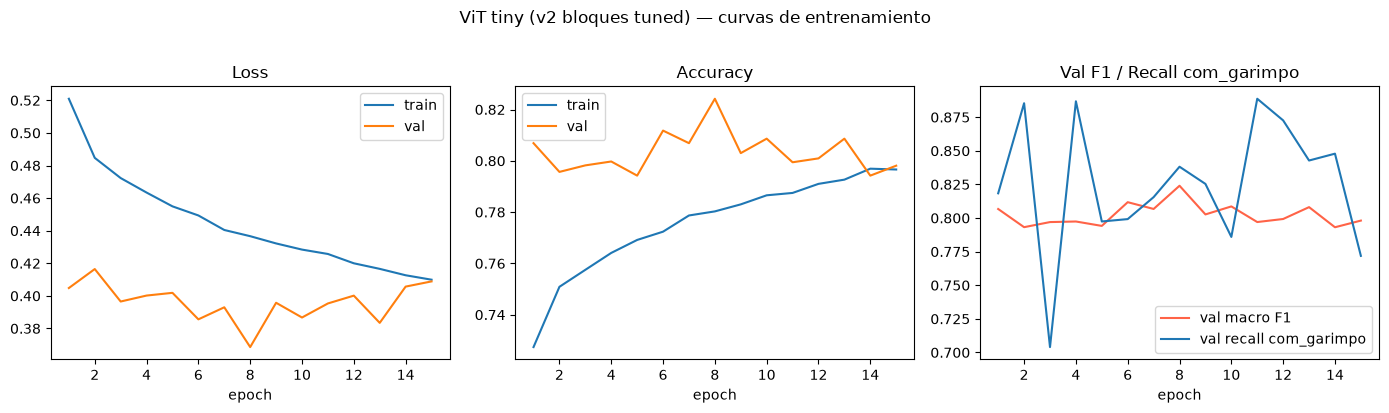


Entrenamiento (v2_bloques_tuned) completado.


In [5]:
results = []
all_epochs_dfs = []
log_lines = [
    "TRAINING MODELS (SPLIT POR BLOQUES, v2) — RESULTADOS",
    f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"Device: {device} | GPU: {gpu_name}",
    f"PyTorch: {torch.__version__}",
    f"Corrida: {RUN_NAME} | Manifiestos: {MANIFEST_DIR}",
    f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE}",
    f"LR CNN={LR_CNN} | LR Transformer={LR_TRANSFORMER}",
    f"Train chips: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}",
    "",
]

for i, model_cfg in enumerate(MODELS, start=1):
    name = model_cfg["name"]
    label = model_cfg["label"]
    lr = model_cfg["lr"]

    print("\n" + "=" * 60)
    print(f"[{i}/{len(MODELS)}] Entrenando: {label} ({name}) | LR={lr}")
    print("=" * 60)

    log_lines += ["=" * 60, f"MODELO: {label} ({name}) | LR={lr}", "=" * 60, ""]

    summary = train_model(
        model_name=name,
        train_loader=train_loader,
        val_loader=val_loader,
        save_dir=MODELS_DIR,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        lr=lr,
    )
    summary["model_label"] = label

    # CSV por epoch de este modelo
    epoch_df = history_to_dataframe(summary)
    epoch_csv = REPORT_DIR / f"epochs_{name}_{RUN_NAME}.csv"
    epoch_df.to_csv(epoch_csv, index=False)
    all_epochs_dfs.append(epoch_df)

    # Líneas de texto por epoch
    for tr, va in zip(summary["history"]["train"], summary["history"]["val"]):
        log_lines.append(format_epoch_line(
            tr["epoch"], MAX_EPOCHS, tr, va, tr.get("time_s", 0)
        ))

    val_history = summary["history"]["val"]
    best_val = next(r for r in val_history if r["epoch"] == summary["best_epoch"])

    log_lines += [
        "",
        f"→ Mejor epoch: {summary['best_epoch']} | val macro F1: {summary['best_val_macro_f1']:.4f}",
        f"→ val accuracy: {best_val['accuracy']:.4f} | val recall com_garimpo: {best_val['recall_com_garimpo']:.4f}",
        f"→ Checkpoint: {summary['checkpoint']}",
        f"→ CSV epochs: {epoch_csv}",
        "",
    ]

    plot_training_curves(summary, FIGURES_DIR / f"{name}_{RUN_NAME}_training_curves.png")

    results.append({
        "model": label,
        "timm_name": name,
        "variant": RUN_NAME,
        "lr": lr,
        "best_epoch": summary["best_epoch"],
        "epochs_run": len(summary["history"]["train"]),
        "val_macro_f1": round(summary["best_val_macro_f1"], 4),
        "val_accuracy": round(best_val["accuracy"], 4),
        "val_recall_com_garimpo": round(best_val["recall_com_garimpo"], 4),
        "val_f1_com_garimpo": round(best_val["f1_com_garimpo"], 4),
        "val_f1_sem_garimpo": round(best_val["f1_sem_garimpo"], 4),
        "checkpoint": summary["checkpoint"],
    })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nEntrenamiento ({RUN_NAME}) completado.")

## 5. Guardar resumen (CSV + TXT)

In [6]:
results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
display(results_df)

# CSV resumen comparativo
summary_csv = REPORT_DIR / f"training_results_summary_{RUN_NAME}.csv"
results_df.to_csv(summary_csv, index=False)

# CSV todas las epochs de los 4 modelos
all_epochs_csv = REPORT_DIR / f"training_epochs_all_models_{RUN_NAME}.csv"
pd.concat(all_epochs_dfs, ignore_index=True).to_csv(all_epochs_csv, index=False)

# TXT legible
best = results_df.iloc[0]
log_lines += [
    "=" * 60,
    f"RESUMEN COMPARATIVO (validation, {RUN_NAME})",
    "=" * 60,
    "",
    results_df.to_string(index=False),
    "",
    f"MEJOR MODELO ({RUN_NAME}): {best['model']} | val macro F1 = {best['val_macro_f1']}",
    f"Checkpoint: {best['checkpoint']}",
]

summary_txt = REPORT_DIR / f"training_results_{RUN_NAME}.txt"
summary_txt.write_text("\n".join(log_lines), encoding="utf-8")

print("\nArchivos guardados:")
print(f"  {summary_csv}")
print(f"  {all_epochs_csv}")
print(f"  {summary_txt}")
print(f"\nMejor modelo ({RUN_NAME}): {best['model']} (val F1={best['val_macro_f1']})")

,model,timm_name,variant,lr,best_epoch,epochs_run,val_macro_f1,val_accuracy,val_recall_com_garimpo,val_f1_com_garimpo,val_f1_sem_garimpo,checkpoint
3,ViT tiny (v2 bloques tuned),vit_tiny_patch16_224,v2_bloques_tuned,0.00003,8,15,0.8240,0.8242,0.8381,0.8298,0.8182,C:\Users\luisg\OneDrive\Documentos\Universidad...
2,Swin Transformer (v2 bloques tuned),swin_tiny_patch4_window7_224,v2_bloques_tuned,0.00003,2,9,0.8185,0.8199,0.8883,0.8345,0.8024,C:\Users\luisg\OneDrive\Documentos\Universidad...
1,ResNet-50 (v2 bloques tuned),resnet50,v2_bloques_tuned,0.00010,9,16,0.8181,0.8183,0.8293,0.8235,0.8127,C:\Users\luisg\OneDrive\Documentos\Universidad...
0,EfficientNet-B0 (v2 bloques tuned),efficientnet_b0,v2_bloques_tuned,0.00010,5,12,0.8141,0.8143,0.7607,0.8073,0.8208,C:\Users\luisg\OneDrive\Documentos\Universidad...



Archivos guardados:
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques_tuned\training_results_summary_v2_bloques_tuned.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques_tuned\training_epochs_all_models_v2_bloques_tuned.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques_tuned\training_results_v2_bloques_tuned.txt

Mejor modelo (v2_bloques_tuned): ViT tiny (v2 bloques tuned) (val F1=0.824)


## 6. Comparación: v1 tuned (split por ráster) vs. v2 (split por bloques)

Los dos conjuntos de validación son distintos, así que la diferencia mide sobre todo **cuánto
cambia la dificultad del problema** al repartir el territorio de otra forma. La comparación
concluyente entre modelos es la de test, en el notebook de evaluación.

In [7]:
baseline_csv = DATA_DIR / "08_reporting" / "v2_bloques" / "training_results_summary_v2_bloques.csv"

if baseline_csv.exists():
    base_df = pd.read_csv(baseline_csv)[["timm_name", "val_macro_f1", "val_accuracy"]].rename(
        columns={
            "val_macro_f1": "val_macro_f1_v2_bloques",
            "val_accuracy": "val_accuracy_v2_bloques",
        }
    )
    tuned_df = results_df[["timm_name", "val_macro_f1", "val_accuracy"]].rename(
        columns={
            "val_macro_f1": "val_macro_f1_v2_bloques_tuned",
            "val_accuracy": "val_accuracy_v2_bloques_tuned",
        }
    )
    comparacion = base_df.merge(tuned_df, on="timm_name", how="outer")
    comparacion["f1_delta_tuned_menos_baseline"] = (
        comparacion["val_macro_f1_v2_bloques_tuned"] - comparacion["val_macro_f1_v2_bloques"]
    ).round(4)
    display(comparacion.sort_values("f1_delta_tuned_menos_baseline", ascending=False))

    compare_csv = REPORT_DIR / f"v2_bloques_vs_{RUN_NAME}_comparison.csv"
    comparacion.to_csv(compare_csv, index=False)
    print(f"\nGuardado: {compare_csv}")
else:
    print(f"No se encontró {baseline_csv}. Ejecuta antes 07_train_bloques.ipynb.")


,timm_name,val_macro_f1_v2_bloques,val_accuracy_v2_bloques,val_macro_f1_v2_bloques_tuned,val_accuracy_v2_bloques_tuned,f1_delta_tuned_menos_baseline
3,vit_tiny_patch16_224,0.8059,0.8059,0.8240,0.8242,0.0181
1,resnet50,0.8074,0.8077,0.8181,0.8183,0.0107
2,swin_tiny_patch4_window7_224,0.8093,0.8097,0.8185,0.8199,0.0092
0,efficientnet_b0,0.8090,0.8091,0.8141,0.8143,0.0051



Guardado: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques_tuned\v2_bloques_vs_v2_bloques_tuned_comparison.csv


## 7. Próximo paso

Evaluar estos checkpoints con `08c_eval_bloques_tuned.ipynb` sobre el mismo `manifest_test.csv`
de `v2_bloques`.
